In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
titanic = pd.read_csv("train.csv")

df = titanic.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df.drop(columns="Cabin", inplace=True)
df.dropna(subset=["Embarked"], inplace=True)

label = LabelEncoder()
df["Sex"] = label.fit_transform(df["Sex"])

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True


In [7]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [8]:
X = df.drop(columns=["Survived","PassengerId","Name","Ticket"])
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,False,True
1,1,0,38.0,1,0,71.2833,False,False
2,3,0,26.0,0,0,7.9250,False,True
3,1,0,35.0,1,0,53.1000,False,True
4,3,1,35.0,0,0,8.0500,False,True


In [9]:
# Decision Tress Classifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

accuracy_score(y_test, model.predict(X_test))

0.7584269662921348

In [10]:
# Pre-Pruning 

max_depths = [2,3,4,5,6,7,8,9]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train , y_train)

    acc = model.score(X_test , y_test)

    print(f"Max_depth = {depth} , Accuracy: {acc}")

min_sample_leaf = [5,10,15,20,25,30]

for leaf in min_sample_leaf:
    model = DecisionTreeClassifier(max_depth=3 , min_samples_leaf=leaf)
    model.fit(X_train , y_train)
    acc = model.score(X_test , y_test)

    print(f"Split: {leaf} , Accuracy: {acc}")

Max_depth = 2 , Accuracy: 0.797752808988764
Max_depth = 3 , Accuracy: 0.8202247191011236
Max_depth = 4 , Accuracy: 0.8146067415730337
Max_depth = 5 , Accuracy: 0.8202247191011236
Max_depth = 6 , Accuracy: 0.8089887640449438
Max_depth = 7 , Accuracy: 0.8146067415730337
Max_depth = 8 , Accuracy: 0.8033707865168539
Max_depth = 9 , Accuracy: 0.7921348314606742
Split: 5 , Accuracy: 0.8202247191011236
Split: 10 , Accuracy: 0.8202247191011236
Split: 15 , Accuracy: 0.7921348314606742
Split: 20 , Accuracy: 0.7808988764044944
Split: 25 , Accuracy: 0.8033707865168539
Split: 30 , Accuracy: 0.8033707865168539


In [11]:
final_model = DecisionTreeClassifier(max_depth= 3 , min_samples_leaf=25)
final_model.fit(X_train , y_train)
final_model.score(X_test , y_test)

0.8033707865168539

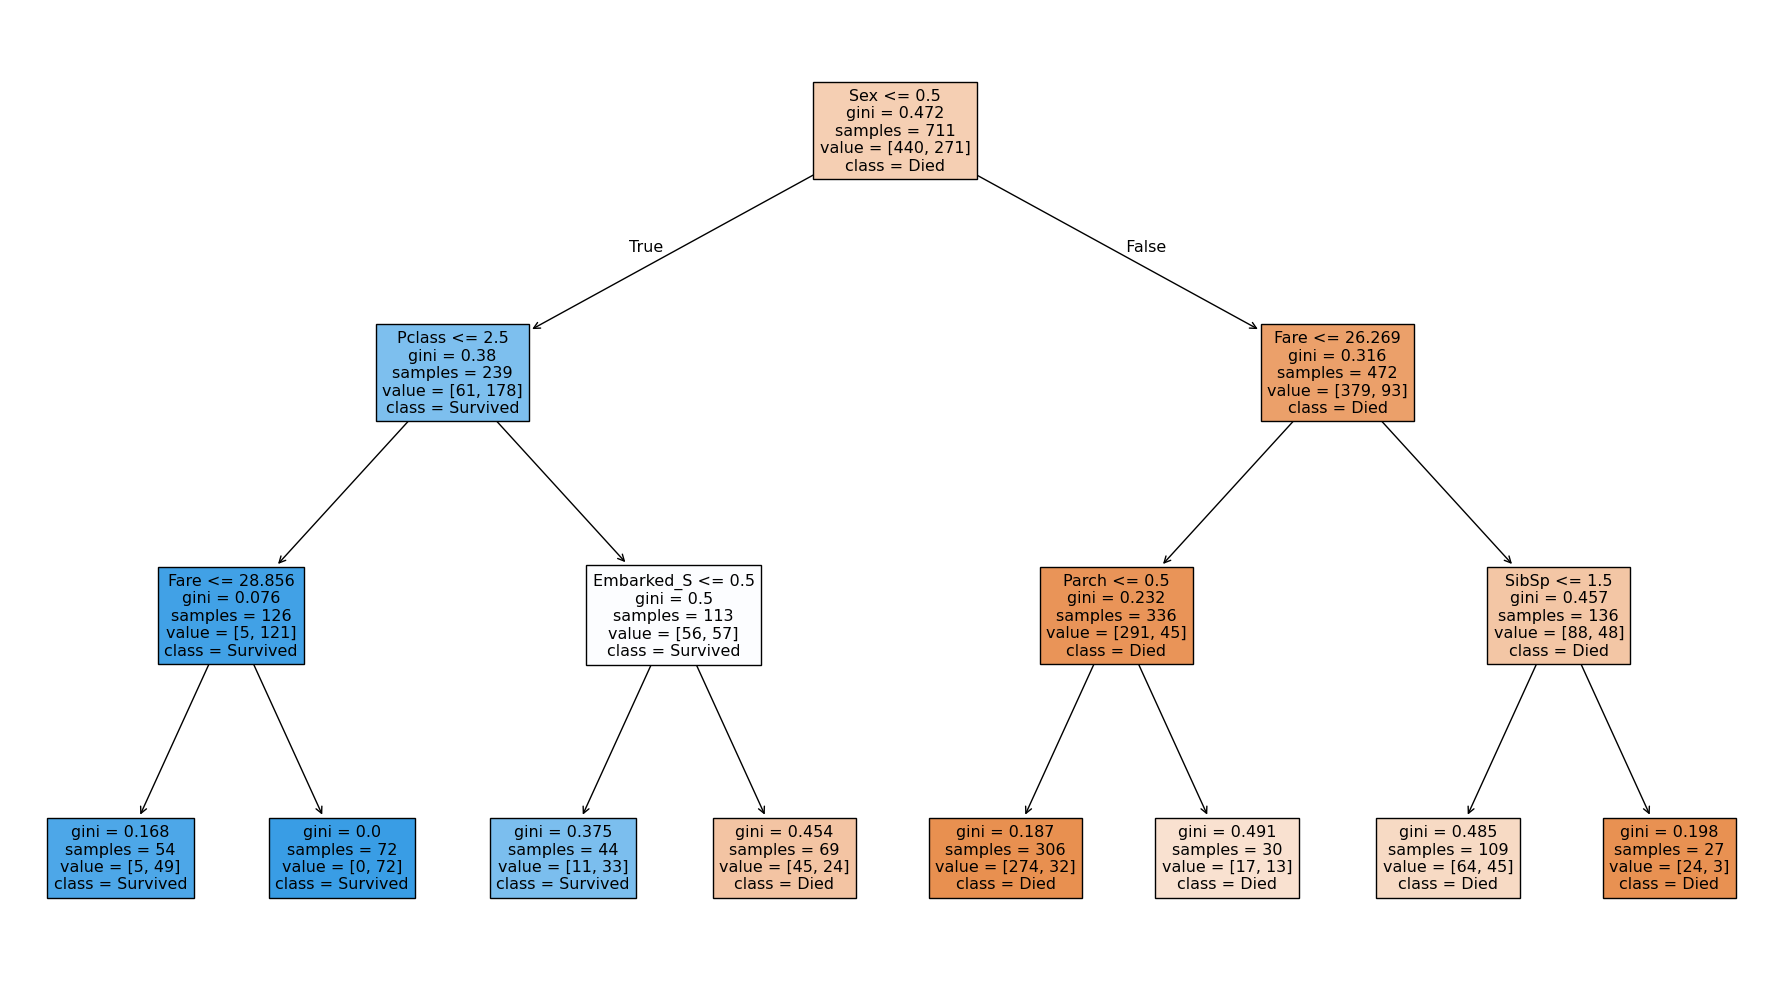

In [12]:
plt.figure(figsize=(18,10))

plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [13]:
# Decision Trees With Post Processing 

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train , y_train)


path = full_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)
ccp_alphas = path.ccp_alphas

In [14]:
trees = []

for alphas in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alphas)
    model.fit(X_train , y_train)
    trees.append((model , alphas))

best_acc = 0
best_alpha = 0 

for model , alphas in trees:
    curr_acc = model.score(X_test , y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alphas


best_alpha

np.float64(0.004937919106251333)

In [15]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train , y_train)
best_model.score(X_test , y_test)


0.8202247191011236

In [16]:
y_pred = best_model.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       109
           1       0.78      0.74      0.76        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178

